<a href="https://colab.research.google.com/github/cs23f011-lang/CSL701-Roll_No_CS16_Machine-Learning-La/blob/Experiments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:- Anisha Atmaram Gawade    
Roll NO:-16  Batch:-01

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


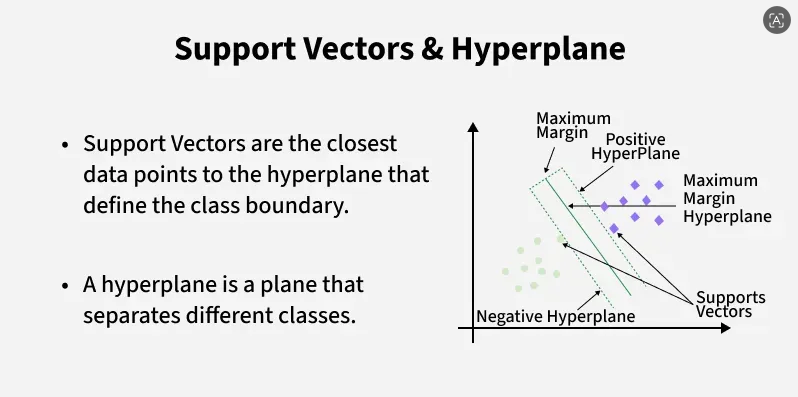
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
# ==========================================
# TASK 1: IMPORT LIBRARIES AND LOAD DATASET
# ==========================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload Iris.csv
from google.colab import files

uploaded = files.upload()

# Get the uploaded CSV file name
file_name = next(iter(uploaded))

# Load the Iris dataset
df = pd.read_csv(file_name)

# Display first 5 rows
print("First 5 rows of Iris Dataset:")
print(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

Saving Iris.csv to Iris (3).csv
First 5 rows of Iris Dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape:
(150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


# Task 2: Explore the Dataset

In [ ]:
# ==========================================
# TASK 2: EXPLORE THE DATASET
# ==========================================

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Display last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Display dataset information
print("\nDataset Information:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display number of samples in each class
print("\nClass Distribution:")
print(df["Species"].value_counts())

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Last 5 rows:
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
145  Iris-virginica  
146  Iris-virginica  
147  Iris-virginica  
1

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# ==========================================
# TASK 3: SELECT FEATURES AND TARGET
# ==========================================

# Remove the Id column
df = df.drop("Id", axis=1)

# Select features
X = df[["SepalLengthCm", "SepalWidthCm",
        "PetalLengthCm", "PetalWidthCm"]]

# Select target
y = df["Species"]

# Display features
print("Features:")
print(X.head())

# Display target
print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
# ==========================================
# TASK 4: SPLIT AND SCALE THE DATA
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select Petal Length and Petal Width
X = df[["PetalLengthCm", "PetalWidthCm"]]

# Target
y = df["Species"]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# Display results
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nData split and scaling completed successfully!")

Training data shape: (120, 2)
Testing data shape: (30, 2)

Data split and scaling completed successfully!


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
# ==========================================
# TASK 5: IMPLEMENT LINEAR SVM
# ==========================================

from sklearn.svm import SVC

# Create Linear SVM model
linear_svm = SVC(kernel="linear", random_state=42)

# Train the model
linear_svm.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred_linear = linear_svm.predict(X_test_scaled)

# Display predictions
print("Predictions:")
print(y_pred_linear)

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [ ]:
# ==========================================
# TASK 6: EVALUATE LINEAR SVM
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_linear)

print("Accuracy:", accuracy)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_linear)

print("\nConfusion Matrix:")
print(cm)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

Accuracy: 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

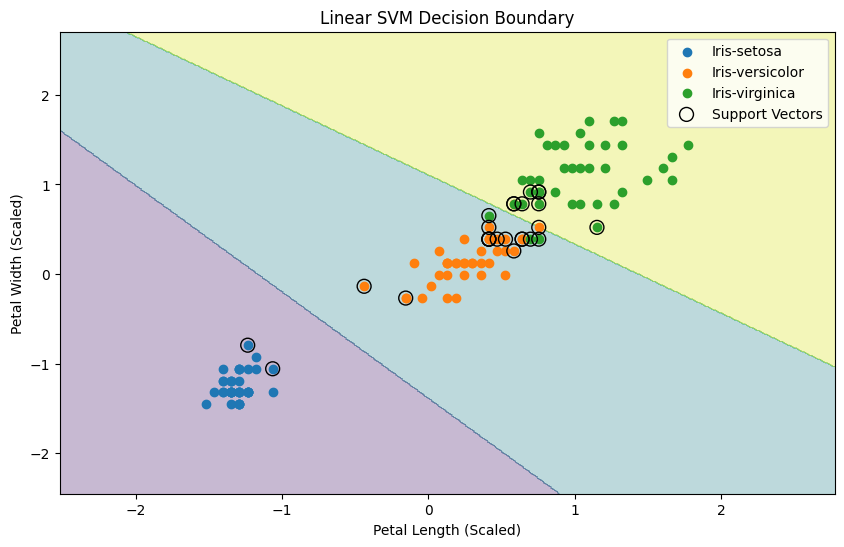

In [ ]:
# ==========================================
# TASK 7: VISUALIZE SVM DECISION BOUNDARY
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ------------------------------------------
# 1. Create 2-D Dataset
# ------------------------------------------

# Select Petal Length and Petal Width
X_2D = df[["PetalLengthCm", "PetalWidthCm"]]

# Target
y_2D = df["Species"]

# ------------------------------------------
# 2. Split the Data
# ------------------------------------------

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.20,
    random_state=42,
    stratify=y_2D
)

# ------------------------------------------
# 3. Scale the Data
# ------------------------------------------

scaler_2D = StandardScaler()

X_train_scaled_2D = scaler_2D.fit_transform(X_train_2D)
X_test_scaled_2D = scaler_2D.transform(X_test_2D)

# ------------------------------------------
# 4. Train Linear SVM
# ------------------------------------------

svm_linear = SVC(kernel="linear", random_state=42)

svm_linear.fit(X_train_scaled_2D, y_train_2D)

# ------------------------------------------
# 5. Create Mesh Grid
# ------------------------------------------

x_min = X_train_scaled_2D[:, 0].min() - 1
x_max = X_train_scaled_2D[:, 0].max() + 1

y_min = X_train_scaled_2D[:, 1].min() - 1
y_max = X_train_scaled_2D[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for every point in the grid
Z = svm_linear.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Convert class names to numbers for plotting
class_names = sorted(y_2D.unique())
class_to_num = {name: i for i, name in enumerate(class_names)}

Z_num = np.vectorize(class_to_num.get)(Z)

# ------------------------------------------
# 6. Plot Decision Boundary
# ------------------------------------------

plt.figure(figsize=(10, 6))

plt.contourf(
    xx,
    yy,
    Z_num,
    alpha=0.3
)

# Plot training data
for class_name in class_names:
    mask = y_train_2D == class_name

    plt.scatter(
        X_train_scaled_2D[mask, 0],
        X_train_scaled_2D[mask, 1],
        label=class_name
    )

# Plot support vectors
plt.scatter(
    svm_linear.support_vectors_[:, 0],
    svm_linear.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

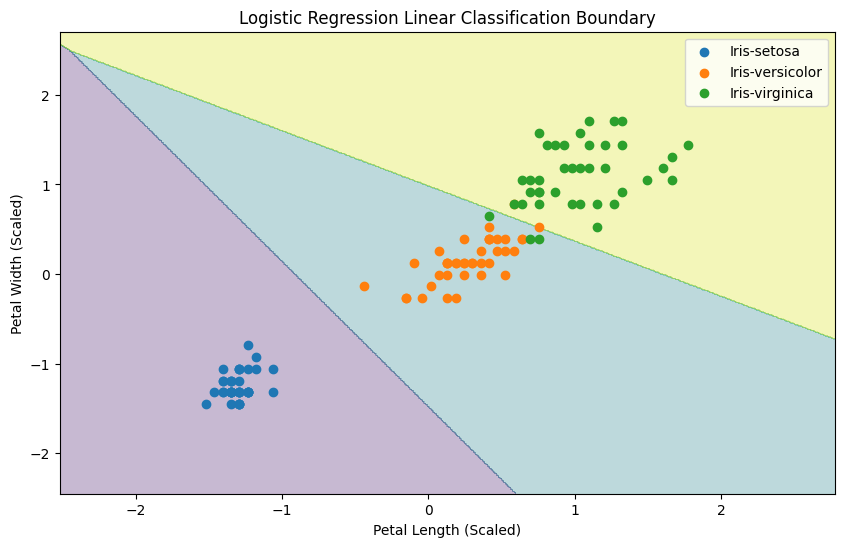

In [ ]:
# ==========================================
# TASK 8: NORMAL LINEAR CLASSIFICATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# ------------------------------------------
# 1. Use the same 2-D features
# ------------------------------------------

# Petal Length and Petal Width
X_2D = df[["PetalLengthCm", "PetalWidthCm"]]

# Target
y_2D = df["Species"]

# ------------------------------------------
# 2. Split the data
# ------------------------------------------

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_2D,
    y_2D,
    test_size=0.20,
    random_state=42,
    stratify=y_2D
)

# ------------------------------------------
# 3. Scale the data
# ------------------------------------------

scaler_lr = StandardScaler()

X_train_scaled_lr = scaler_lr.fit_transform(X_train_2D)
X_test_scaled_lr = scaler_lr.transform(X_test_2D)

# ------------------------------------------
# 4. Train Logistic Regression
# ------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled_lr, y_train_2D)

# ------------------------------------------
# 5. Create mesh grid
# ------------------------------------------

x_min = X_train_scaled_lr[:, 0].min() - 1
x_max = X_train_scaled_lr[:, 0].max() + 1

y_min = X_train_scaled_lr[:, 1].min() - 1
y_max = X_train_scaled_lr[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict each point in the grid
Z = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Convert class names to numbers
class_names = sorted(y_2D.unique())
class_to_num = {name: i for i, name in enumerate(class_names)}

Z_num = np.vectorize(class_to_num.get)(Z)

# ------------------------------------------
# 6. Plot decision boundary
# ------------------------------------------

plt.figure(figsize=(10, 6))

plt.contourf(
    xx,
    yy,
    Z_num,
    alpha=0.3
)

# Plot training data
for class_name in class_names:

    mask = y_train_2D == class_name

    plt.scatter(
        X_train_scaled_lr[mask, 0],
        X_train_scaled_lr[mask, 1],
        label=class_name
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Linear Classification Boundary")

plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

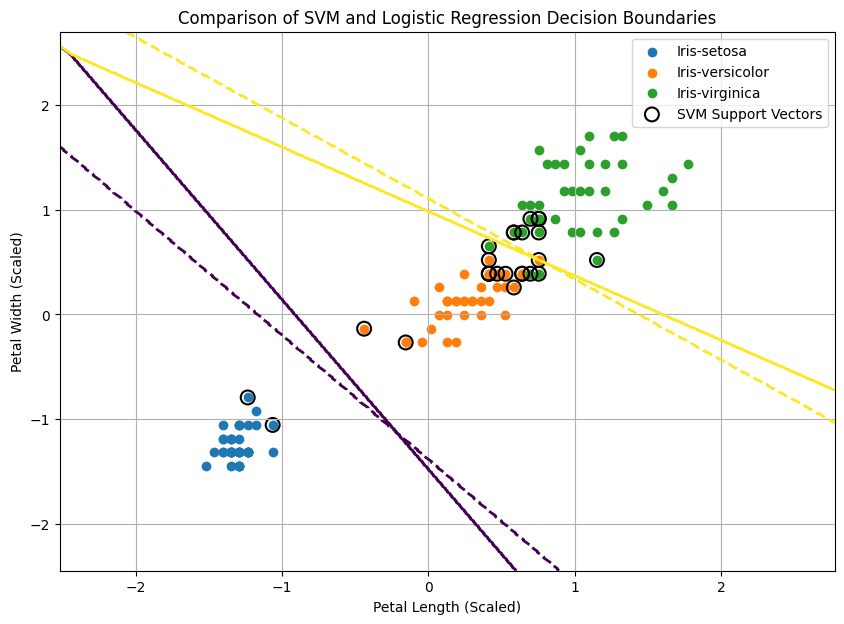

In [ ]:
# ==========================================
# TASK 9: COMPARE SVM AND LOGISTIC REGRESSION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# 1. Select Petal Length and Petal Width
# ------------------------------------------

X = df[["PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

# ------------------------------------------
# 2. Split the data
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# 3. Scale the data
# ------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------
# 4. Train Linear SVM
# ------------------------------------------

svm_model = SVC(kernel="linear")

svm_model.fit(X_train_scaled, y_train)

# ------------------------------------------
# 5. Train Logistic Regression
# ------------------------------------------

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

# ------------------------------------------
# 6. Create Mesh Grid
# ------------------------------------------

x_min = X_train_scaled[:, 0].min() - 1
x_max = X_train_scaled[:, 0].max() + 1

y_min = X_train_scaled[:, 1].min() - 1
y_max = X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Create grid points
grid = np.c_[xx.ravel(), yy.ravel()]

# ------------------------------------------
# 7. Predict Grid Points
# ------------------------------------------

Z_svm = svm_model.predict(grid)
Z_lr = logistic_model.predict(grid)

# Convert class names to numbers
class_names = sorted(y.unique())

class_to_num = {
    class_name: i
    for i, class_name in enumerate(class_names)
}

Z_svm = np.array([class_to_num[value] for value in Z_svm])
Z_lr = np.array([class_to_num[value] for value in Z_lr])

# IMPORTANT: Reshape predictions into 2-D
Z_svm = Z_svm.reshape(xx.shape)
Z_lr = Z_lr.reshape(xx.shape)

# ------------------------------------------
# 8. Plot Decision Boundaries
# ------------------------------------------

plt.figure(figsize=(10, 7))

# SVM boundary
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=[0.5, 1.5],
    linestyles="--",
    linewidths=2
)

# Logistic Regression boundary
plt.contour(
    xx,
    yy,
    Z_lr,
    levels=[0.5, 1.5],
    linestyles="-",
    linewidths=2
)

# ------------------------------------------
# 9. Plot Data Points
# ------------------------------------------

for class_name in class_names:

    mask = y_train == class_name

    plt.scatter(
        X_train_scaled[mask, 0],
        X_train_scaled[mask, 1],
        label=class_name
    )

# ------------------------------------------
# 10. Plot SVM Support Vectors
# ------------------------------------------

plt.scatter(
    svm_model.support_vectors_[:, 0],
    svm_model.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="SVM Support Vectors"
)

# ------------------------------------------
# 11. Labels and Title
# ------------------------------------------

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")

plt.title(
    "Comparison of SVM and Logistic Regression Decision Boundaries"
)

plt.legend()
plt.grid(True)
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:
# ==========================================
# TASK 10: COMPARE PERFORMANCE
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ------------------------------------------
# 1. Make predictions
# ------------------------------------------

svm_predictions = svm_model.predict(X_test_scaled)

logistic_predictions = logistic_model.predict(X_test_scaled)

# ------------------------------------------
# 2. Calculate Accuracy
# ------------------------------------------

svm_accuracy = accuracy_score(y_test, svm_predictions)
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("==========================================")
print("ACCURACY COMPARISON")
print("==========================================")

print("Linear SVM Accuracy      :", svm_accuracy)
print("Logistic Regression Accuracy:", logistic_accuracy)

# ------------------------------------------
# 3. Confusion Matrix - SVM
# ------------------------------------------

print("\n==========================================")
print("LINEAR SVM - CONFUSION MATRIX")
print("==========================================")

svm_cm = confusion_matrix(y_test, svm_predictions)

print(svm_cm)

# ------------------------------------------
# 4. Confusion Matrix - Logistic Regression
# ------------------------------------------

print("\n==========================================")
print("LOGISTIC REGRESSION - CONFUSION MATRIX")
print("==========================================")

logistic_cm = confusion_matrix(y_test, logistic_predictions)

print(logistic_cm)

# ------------------------------------------
# 5. Classification Report - SVM
# ------------------------------------------

print("\n==========================================")
print("LINEAR SVM - CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_test,
        svm_predictions
    )
)

# ------------------------------------------
# 6. Classification Report - Logistic Regression
# ------------------------------------------

print("\n==========================================")
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

ACCURACY COMPARISON
Linear SVM Accuracy      : 0.9333333333333333
Logistic Regression Accuracy: 0.9333333333333333

LINEAR SVM - CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

LOGISTIC REGRESSION - CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

LINEAR SVM - CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


LOGISTIC REGRESSION - CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy            

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.